In [1]:
import numpy as np
from matplotlib.pyplot import *
# from cmblensplus/utils/
import constant as c
import binning as bn
import plottools as pl
# others
import local
import tools_delens
import tools_cmb

In [2]:
import importlib
importlib.reload(tools_delens)

<module 'tools_delens' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_delens.py'>

In [3]:
lbmin, lbmax, bN = 2, 190, 15
simN = 500

In [4]:
pobj = local.analysis()
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename(method='cinv')

In [5]:
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')

In [6]:
label = {'klb':'$LiteBIRD$ internal',
         'cib':r'$+$ CIB',
         'gal':r'$+\,\delta_{\rm g}$',
         'ext':r'$+$ CIB $+\,\delta_{\rm g}$',
         'all':r'$+$ CIB $+\,\delta_{\rm g}\,+$ CMB-S4'
        }

In [7]:
OCb, DCb, RCb = {}, {}, {}
for wmass in dobj.ctypes:
    if wmass == 'all': 
        area = 'cmball'
    else:
        area = 'lbfull'
    # read cls
    Ob, Db, Rb = tools_delens.load_clbbs(dobj.cl[area][wmass],mb,simN,1.)
    OCb[wmass] = Ob
    DCb[wmass] = Db
    RCb[wmass] = Rb

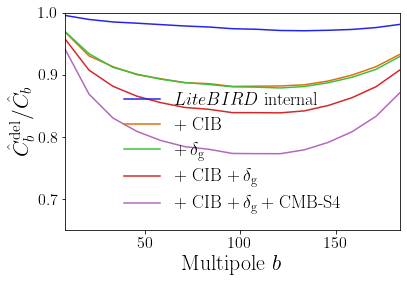

In [8]:
pl.plot_1dstyle(fsize=[6,5],usetex=True,xmin=mb.bc[0],xmax=mb.bc[-1],ymin=.65,ymax=1,
                xlab=r'Multipole $b$',ylab=r'$\hat{C}^{\rm del}_b/\hat{C}_b$',
                xlabsize=22,ylabsize=22,
                xticks_labsize=16,yticks_labsize=16,legend_size=18)
rcParams["font.family"] = "Arial"
for wmass in dobj.ctypes:
    plot(mb.bc,np.mean(DCb[wmass]/OCb[wmass],axis=0),label=label[wmass])
legend(ncol=1)
savefig('fig_clbb.pdf',bbox_inches = 'tight', pad_inches = 0.1)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


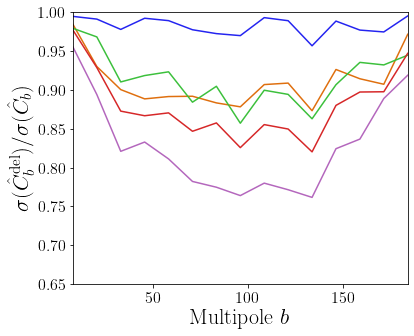

In [9]:
pl.plot_1dstyle(fsize=[6,5],usetex=True,xmin=mb.bc[0],xmax=mb.bc[-1],ymin=.65,ymax=1.,
                xlab=r'Multipole $b$',ylab=r'$\sigma(\hat{C}^{\rm del}_b)/\sigma(\hat{C}_b)$',
                xlabsize=22,ylabsize=22,
                xticks_labsize=16,yticks_labsize=16,legend_size=18)
rcParams["font.family"] = "Arial"
for wmass in dobj.ctypes:
    plot(mb.bc,np.std(DCb[wmass],axis=0)/np.std(OCb[wmass],axis=0))
#plot(mb.bc,.001*np.mean(RCb[wmass],axis=0)/np.std(OCb[wmass],axis=0),label=r'$r=0.001$',color='k',ls='--')
legend()
savefig('fig_vlbb.pdf',bbox_inches = 'tight', pad_inches = 0.1)